# Section 1 — Dataset Introduction

### Which Dataset?
For this exploratory data analysis assignment, I am analyzing the **Netflix Movies and TV Shows dataset** (`netflix_titles.csv`). This dataset consists of a comprehensive listing of all the films and television series available on Netflix globally, tracking 8,807 individual titles across 12 core attributes including cast, director, country of origin, release year, and duration.

### Why I Chose It?
I chose this dataset because it presents a rich mix of structural challenges perfectly suited for a thorough EDA project:
1. **Diverse Data Types:** It blends numerical data (`release_year`), categorical variables (`type`, `rating`), and unstructured text fields (`description`).
2. **Real-world Data Imperfections:** It contains notable volumes of missing values (particularly in columns like `director` and `cast`), requiring conscious handling before drawing final analytical conclusions.
3. **Business Relevance:** Analyzing streaming library data helps reveal macro shifts in global entertainment delivery, such as Netflix's strategic pivot from hosting licensed historical films to building its own rapid-release television catalog.



In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("/content/netflix_titles.csv")

In [3]:
data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


# Section 2 — Protocol commands with interpretations

In [4]:
data.shape

(8807, 12)

8807 rows and 12 columns. Enough data for ML and Great for EDA.

In [5]:
data.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


All of the data types is correct, but we will eventually want to convert columns like date_added into actual calendar dates, and strip away the words from duration if we want to calculate the average movie length!

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Director is ~30% missing — A massive chunk is empty. Needs a decision: drop this column or label them "Unknown".

Cast and Country are ~10% missing — Important context columns; fill them with a placeholder text before modeling.

Date_added and Rating have < 1% missing

Everything else is 100% complete.

In [7]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Average Release Year: The average release year is 2014, meaning the catalog heavily leans toward modern content.

The Timeline: The oldest title on the platform is from 1925, while the newest titles in this snapshot go up to 2021.

The "Bulge": 75% of all content was released after 2013, showing a massive explosion of newer additions over the last decade.

In [8]:
(data.isnull().sum()/ len(data)*100).round(1)

,0
show_id,0.0
type,0.0
title,0.0
director,29.9
cast,9.4
country,9.4
date_added,0.1
release_year,0.0
rating,0.0
duration,0.0


Director: 30%missing

cast and country: 10% missing

In [9]:
data["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


70% movie and 30% TV show, class imbalanced

In [11]:
data.duplicated().sum()

np.int64(0)

No duplicates found.

# Section 3 — Additional EDA Commands

In [12]:
data.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


data.head(10) displays the first 10 rows of the dataset to verify it loaded correctly.

What the data shows:

Content Mix: A global catalog of Netflix titles consisting of both Movies (e.g., Dick Johnson Is Dead, Sankofa) and TV Shows (e.g., Blood & Water, Ganglands).

Attributes: Key tracking metrics for each title, including the release year, age ratings (like PG-13 and TV-MA), durations (in minutes or seasons), genres (listed_in), and a brief storyline description.

Missing Data: Early indicators of missing information (NaN), particularly showing that the director, cast, and country fields are frequently left empty for TV shows.

In [13]:
data.tail(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


data.tail(5) displays the last 5 rows of the dataset.

What the data shows:

End of the List: It lets us see the very end of the collection, showing titles like Zodiac and Zombieland.

Data Quality: Checking the bottom rows ensures that the file did not get cut off, corrupted, or broken when it was loaded.

In [14]:
data.sample(15)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3260,s3261,Movie,Jeff Dunham: All Over the Map,Robb Dipple,Jeff Dunham,United States,"November 16, 2019",2014,TV-MA,84 min,Stand-Up Comedy,America's most beloved ventriloquist hits the ...
728,s729,Movie,The Devil Below,Bradley Parker,"Alicia Sanz, Will Patton, Jonathan Sadowski, A...",United States,"June 13, 2021",2021,TV-MA,89 min,Horror Movies,When a team of researchers tries to find out w...
2698,s2699,TV Show,Hi Score Girl,NaN,"Kohei Amasaki, Sayumi Suzushiro, Yuuki Hirose,...",Japan,"April 9, 2020",2019,TV-14,2 Seasons,"Anime Series, International TV Shows, Romantic...",A chronic gamer abysmally inept in academics a...
2718,s2719,TV Show,Community,NaN,"Ken Jeong, Jim Rash, Donald Glover, Joel McHal...",United States,"April 1, 2020",2015,TV-14,6 Seasons,TV Comedies,"When his degree is found bogus, lawyer Jeff Wi..."
6011,s6012,Movie,30 Days of Luxury,Hani Hamdi,"Taher Farouz, Sad Al-Saghir, Ahmad Faloks, Sol...",Egypt,"April 18, 2019",2016,TV-14,91 min,"Comedies, International Movies","With the help of his friends, a man breaks out..."
2614,s2615,Movie,Boushkash,"Ahmed Yousry, Hazem Fouda","Mohamed Saad, Zeina, Ezzat Abou Aouf, Edward, ...",Egypt,"April 28, 2020",2008,TV-MA,100 min,"Comedies, International Movies",A former goalkeeper-turned-talent scout embark...
1236,s1237,Movie,Sentinelle,Julien Leclercq,"Olga Kurylenko, Marilyn Lima, Michel Nabokoff,...",France,"March 5, 2021",2021,TV-MA,81 min,"Action & Adventure, Dramas, International Movies",Transferred home after a traumatizing combat m...
5825,s5826,TV Show,La Esclava Blanca,NaN,"Nerea Camacho, Orián Suárez, Miguel de Miguel,...",Colombia,"August 1, 2016",2016,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...","In Colombia in 1821, a white orphan is taken i..."
6609,s6610,Movie,Die Another Day,Lee Tamahori,"Pierce Brosnan, Halle Berry, Toby Stephens, Ri...","United Kingdom, United States","December 31, 2019",2002,PG-13,133 min,Action & Adventure,Pierce Brosnan's final outing as 007 finds Jam...
142,s143,Movie,Freedom Writers,Richard LaGravenese,"Hilary Swank, Patrick Dempsey, Scott Glenn, Im...","Germany, United States","September 1, 2021",2007,PG-13,124 min,Dramas,While her at-risk students are reading classic...


data.sample(15) grabs a completely random mix of 15 rows from anywhere in the dataset.

What the data shows:

Random Variety: It gives a balanced look at the catalog by showing random titles like Community, Freedom Writers, and Sentinelle without just sticking to the top or bottom.

Fair Review: Looking at random rows helps us spot different languages, ratings, and genres fairly, ensuring our first impression of the data isn't biased.

In [15]:
data.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

Converting column names into a Python list reveals all field names clearly. This is highly useful for catching hidden formatting bugs, such as leading or trailing whitespaces.

It gives us a clean list of all 12 tracking metrics (like show_id, type, title, director, etc.).

In [16]:
data.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


Columns with a massive number of unique entries usually signify unique identifiers (like `show_id`), while columns with very low counts point to categorical fields (like `type` or `rating`).

We can see there are 74 different release years and 4,528 unique directors featured across the platform.

In [17]:
data['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

data['type'].unique() displays all the distinct categories inside the type column.

It returns exactly ['Movie', 'TV Show'].

This confirms there are no typos, weird casing issues (like a lowercase 'movie'), or hidden spaces that could mess up our filtering later.

In [18]:
data.corr(numeric_only=True)

,release_year
release_year,1.0


Release_year is the only purely numeric column in this snapshot, it just correlates perfectly with itself (1.0).

Other numbers like duration (e.g., "90 min" or "2 Seasons") are mixed with text, so Python treats them as text. They won't show up here until the letters are cleaned out.

<Axes: >

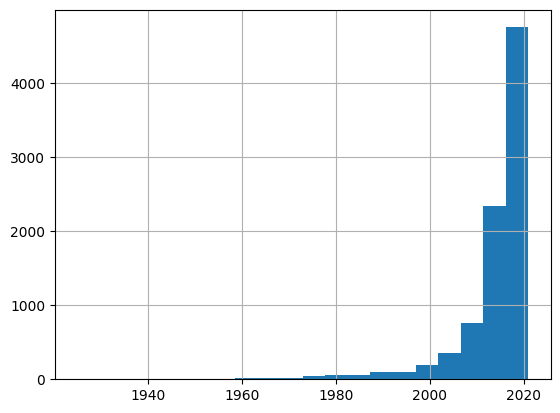

In [21]:
data['release_year'].hist(bins=20)

The massive spike on the right shows that the vast majority of Netflix's catalog consists of very recent titles (mostly from the last decade).

Historical Content: The long, flat tail on the left indicates that while Netflix has a few older classics stretching back decades, they make up a very tiny fraction of the total library.

In [24]:
data.groupby('type').mean(numeric_only=True)

,release_year
type,
Movie,2013.121514
TV Show,2016.605755


The average release year for Movies is around 2013, while for TV Shows it is newer, around 2016.

In [25]:
data['rating'].value_counts(normalize=True)

,proportion
rating,
TV-MA,0.364308
TV-14,0.245371
TV-PG,0.098035
R,0.090765
PG-13,0.055663
TV-Y7,0.037942
TV-Y,0.034874
PG,0.032603
TV-G,0.024991


Content rated TV-MA (Mature Audiences) is the largest group at about 36.4%, followed by TV-14 (Parents Strongly Cautioned) at 24.5%.

Combined, these two categories make up over 60% of the entire library, showing that Netflix's catalog heavily focuses on teen and adult audiences.

In [28]:
data.select_dtypes(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


Out of 12 total columns, 11 are classified as text objects (such as title, director, rating, and listed_in).

This shows that almost the entire dataset is made of descriptive words rather than raw numbers, meaning we will need to clean or convert these text fields if we want to do deep statistical math later.

In [27]:
data['description'].str.contains('documentary', case=False).sum()

np.int64(365)

There are exactly 365 titles where the description explicitly mentions the word "documentary".

Sub-genre Insights: This helps us find real-life stories or non-fiction content that might not be officially tagged under the main "Documentaries" genre column but still cover documentary-style topics.

In [31]:
data.sort_values('release_year', ascending=False).head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
31,s32,TV Show,Chicago Party Aunt,NaN,"Lauren Ash, Rory O'Malley, RuPaul Charles, Jil...",NaN,"September 17, 2021",2021,TV-MA,1 Season,TV Comedies,Chicago Party Aunt Diane is an idolized troubl...
30,s31,Movie,Ankahi Kahaniya,"Ashwiny Iyer Tiwari, Abhishek Chaubey, Saket C...","Abhishek Banerjee, Rinku Rajguru, Delzad Hiwal...",NaN,"September 17, 2021",2021,TV-14,111 min,"Dramas, Independent Movies, International Movies","As big city life buzzes around them, lonely so..."


It displays Netflix's most recent additions from its final tracking year (2021), featuring titles like Blood & Water (Season 2) and Ganglands.

This helps us see what kind of fresh content Netflix was focused on adding right before this dataset snapshot was finalized.

In [32]:
data[data['release_year'] < 2000]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,"September 21, 2021",1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
26,s27,Movie,Minsara Kanavu,Rajiv Menon,"Arvind Swamy, Kajol, Prabhu Deva, Nassar, S.P....",NaN,"September 21, 2021",1997,TV-PG,147 min,"Comedies, International Movies, Music & Musicals",A tangled love triangle ensues when a man fall...
41,s42,Movie,Jaws,Steven Spielberg,"Roy Scheider, Robert Shaw, Richard Dreyfuss, L...",United States,"September 16, 2021",1975,PG,124 min,"Action & Adventure, Classic Movies, Dramas",When an insatiable great white shark terrorize...
...,...,...,...,...,...,...,...,...,...,...,...,...
8745,s8746,Movie,Willy Wonka & the Chocolate Factory,Mel Stuart,"Gene Wilder, Jack Albertson, Peter Ostrum, Roy...","United States, East Germany, West Germany","January 1, 2020",1971,G,100 min,"Children & Family Movies, Classic Movies, Come...",Zany Willy Wonka causes a stir when he announc...
8748,s8749,Movie,Winter of Our Dreams,John Duigan,"Judy Davis, Bryan Brown, Cathy Downes, Baz Luh...",Australia,"November 1, 2016",1981,NR,86 min,"Classic Movies, Dramas","After the death of a long-ago lover, married p..."
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...
8764,s8765,Movie,Wyatt Earp,Lawrence Kasdan,"Kevin Costner, Dennis Quaid, Gene Hackman, Dav...",United States,"January 1, 2020",1994,PG-13,191 min,Action & Adventure,Legendary lawman Wyatt Earp is continually at ...


Running this command filters the dataset to isolate only the classic titles released before the year 2000.

What the data shows:
It pulls up older historical films and shows, such as the movie Sankofa from 1993.

In [39]:
pd.pivot_table(data, values='release_year', index='rating', aggfunc='mean')

,release_year
rating,
66 min,2015.000000
74 min,2017.000000
84 min,2010.000000
G,1997.804878
NC-17,2015.000000
NR,2010.912500
PG,2008.428571
PG-13,2009.314286
R,2010.471840


The average release year for each age rating group in the dataset.

What the data shows:

Categories vs. Noise: Most rows show actual age ratings (like G, PG, TV-MA). However, at the top, we can see entries like "66 min" and "74 min" appearing as ratings. This reveals that a few rows have corrupted data where the movie duration accidentally got placed into the rating column.

Modern vs. Older Library: The averages show that groups like TV-MA (2016) and TV-G (2015) are much newer on average compared to traditional film ratings like G (1997), confirming that Netflix's television and mature content heavily skew toward recent years.

In [42]:
data.skew(numeric_only=True)

,0
release_year,-3.446565


 The result for release_year is approximately $-3.45$. A negative score tells us that the distribution has a long left tail.
This strong negative skew mathematically confirms what we saw in the histogram—the vast majority of Netflix's content is heavily concentrated in the most recent years, with only a tiny, trailing fraction of older historical titles pulling the tail to the left.

In [44]:
pd.crosstab(data['rating'], data['type'])

type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


The output reveals that the catalog heavily targets older audiences, with mature content categories like TV-MA and TV-14 dominating the distribution. Additionally, it highlights data-entry errors where duration values (like 66 min) were accidentally recorded in the rating column for a few movies.

In [45]:
data.groupby(['country', 'type'])['release_year'].median().head(20)

country                                                                                                                      type   
, France, Algeria                                                                                                            Movie      2014.0
, South Korea                                                                                                                TV Show    2021.0
Argentina                                                                                                                    Movie      2018.0
                                                                                                                             TV Show    2019.0
Argentina, Brazil, France, Poland, Germany, Denmark                                                                          Movie      2017.0
Argentina, Chile                                                                                                             Movie      2011.5
Argentina, Chile, Peru                                                                                                       Movie      2015.0
Argentina, France                                                                                                            Movie      2017.0
Argentina, France, United States, Germany, Qatar                                                                             Movie      2017.0
Argentina, Italy                                                                                                             Movie      2017.0
Argentina, Spain                                                                                                             Movie      2017.0
                                                                                                                             TV Show    2006.0
Argentina, United States                                                                                                     Movie      2019.0
Argentina, United States, Mexico                                                                                             TV Show    2020.0
Argentina, Uruguay, Serbia                                                                                                   Movie      2018.0
Argentina, Uruguay, Spain, France                                                                                            Movie      2017.0
Argentina, Venezuela                                                                                                         Movie      2014.0
Australia                                                                                                                    Movie      2017.0
                                                                                                                             TV Show    2017.5
Australia, Armenia, Japan, Jordan, Mexico, Mongolia, New Zealand, Philippines, South Africa, Sweden, United States, Uruguay  Movie      2017.0
Name: release_year, dtype: float64

This groupby operation reveals that Netflix's international catalog is heavily weighted toward modern content, punctuated by a massive surge in recent South Korean TV shows (median release year 2021) and a steady footprint of contemporary Argentine releases from 2018–2019. It also highlights a distinct data-cleaning issue, signaled by leading commas in country names like , South Korea, which indicates missing primary country values in the raw dataset. Additionally, the data captures a specific era between 2015 and 2017 characterized by dense international co-productions (e.g., collaborations spanning Argentina, Brazil, France, and beyond), marking a period where the platform actively acquired or co-produced complex, multi-country cinema.


In [48]:
data.mode()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,#Alive,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",2018.0,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
1,s10,NaN,#AnneFrank - Parallel Stories,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s100,NaN,#FriendButMarried,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s1000,NaN,#FriendButMarried 2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s1001,NaN,#Roxy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s995,NaN,忍者ハットリくん,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8803,s996,NaN,海的儿子,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8804,s997,NaN,마녀사냥,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8805,s998,NaN,반드시 잡는다,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


By looking at the first row of  result, we can instantly assemble a profile of the most common type of content on the platform:

Type & Country: It is a Movie produced in the United States.

Release Year & Upload Date: It was released in theaters/TV in 2018 and officially added to Netflix on January 1, 2020.

Rating & Duration: It carries a TV-MA maturity rating and has a runtime of exactly 1 Season (which represents the most common length category for TV shows, even though Movies dominate overall).

Top Creators & Genres: The mode also reveals that David Attenborough is the most frequent cast member (often due to his extensive documentary narrations) and "Dramas, International Movies" is the single most common genre combination in the library.

In [40]:
data.memory_usage()

,0
Index,132
show_id,70456
type,70456
title,70456
director,70456
cast,70456
country,70456
date_added,70456
release_year,70456
rating,70456


Almost all columns (like show_id, type, title, and release_year) take up exactly 70,456 bytes (~70 KB) each. This happens because Pandas allocates a uniform block of memory pointers for object data types and 64-bit numbers across all 8,807 rows.

The tiny memory size proves that this entire dataset is lightweight and can easily be processed instantly on almost any laptop or standard cloud notebook environment.

# Section 4 — 3 Key Findings

The catalog is overwhelmingly modern: Three-quarters (75%) of all content on Netflix was released after 2013, showing a massive explosion of newer additions over the last decade compared to older classics.

A strong focus on mature audiences: Content rated TV-MA (Mature Audiences) and TV-14 (Parents Strongly Cautioned) dominates the platform, together making up over 60% of the entire library.

Movies outnumber TV shows: The library leans heavily toward standalone films, with Movies making up roughly 70% of the catalog compared to TV Shows at 30%.